In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import numpy as np
import pandas as pd
import sys
import random
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습 과장 그래프
from sklearn.metrics import confusion_matrix # 혼동 행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split # 데이터 분리

# 이진분류
```
1. 데이터 셋 생성 & 전처리 (pip show openpyxl, conda activate ml-dl-nlp, pip install openpyxl
    엑셀 -> 데이터프레임 -> ?처리(df.replace('?', np.nan) -> 결측치 처리
       -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측)
```

## 컬럼명 의미 및 설명
- cp 흉통의 유형 (Chest Pain type)
    * 0: 전형적 협심증 / 1: 비전형적 협심증 / 2: 비심장성 흉통 / 3: 무증상
- treshtbps 안정 시 수축기 혈압 (Resting Blood Pressure in mm Hg)
- chol 혈청 콜레스테롤 수치 (Serum Cholesterol in mg/dl)
- fbs 공복혈당 120mg/dl 이상 여부 (Fasting Blood Sugar) - 1: Yes, 0: No
- restecg 안정 시 심전도 결과 (Resting Electrocardiographic Results)
    * 0: 정상 / 1: ST-T 이상 / 2: 좌심실 비대 가능성
- thalach 최대 심박수 (Maximum Heart Rate Achieved)
- exang 운동 중 협심증 여부 (Exercise Induced Angina) - 1: 있음, 0: 없음
- oldpeak 운동 후 ST 감소 정도 (ST Depression induced by exercise relative to rest)
- slope ST segment의 기울기 (Slope of the peak exercise ST segment)
    * 1: 수평 / 2: 상승 / 3: 하강
- ca 형광투시검사에서 관찰된 주요 혈관 수 (Number of major vessels colored by fluoroscopy)
- hsl (일반적으로 thal로 표기됨) 지혈소 상태 (Thalassemia)
    * 3: 정상 / 6: 고정결함 / 7: 가역적 결함
- heartDisease 심장병 여부 (Target Variable)
    * 1: 심장병 있음 / 0: 없음

# 1. 데이터 셋 생성 & 전처리
 엑셀 -> 데이터프레임 -> ?처리(df.replace('?',np.nan) -> 결측치 처리
 -> X, y 분리 -> X변수 스케일조정 -> train_test_split함수로 학습셋과 테스트셋분리

In [3]:
def fill_nan(row):
    'row에 중간값 성별 median_data[성별, 열이름]으로 대체'
    pd.options.mode.copy_on_write = True
    if row.isna()['chol']:
        row['chol'] = median_data.loc[row.sex, 'chol']
    if row.isna()['ca']:
        row['ca'] = median_data.loc[row['sex'], 'ca']
    if row.isna()['hsl']:
        row['hsl'] = median_data.loc[row['sex'], 'hsl']
    return row

In [4]:
# 데이터 셋 생성 & 전처리 (pip show openpyxl, conda activate ml-dl-nlp, pip install openpyxl
#     엑셀 -> 데이터프레임 -> ?처리(df.replace('?', np.nan) -> 결측치 처리
#        -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
dataset = pd.read_excel('data/heart-disease.xlsx')
# display(dataset.head())
dataset.isin(['?']).any() # 물음표가 있는 열 여부 -> chol 1, ca 4, hsl 의 행에..2개
dataset = dataset.replace('?', np.nan)
# dataset.info()

# 결측치가 있는 데이터 성별 median값으로 대체
dataset[dataset['chol'].isna() | dataset['ca'].isna() | dataset['hsl'].isna()].head()
median_data = dataset.groupby('sex')[['chol', 'ca', 'hsl']].median()
# display(median_data.head())
dataset = dataset.apply(fill_nan, axis=1)
# dataset.info()

# Target 변수의 분포 (0:음성, 1: 양성)
print(dataset['heartDisease'].value_counts(normalize=True))

# X, y 분리위한 셔플
# permutation_indices = np.random.permutation(dataset.shape[0])
# dataset.index=[permutation_indices]
# dataset = dataset.sort_index()
# display(dataset.head())

# X변수 스케일 조정
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values
print(X.shape, y.shape)
scaler_x = MinMaxScaler()
scaled_X = scaler_x.fit_transform(X)

# scaled_X, y를 학습셋, 테스트셋 8:2으로 분리
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                                   y,
                                                   test_size=0.20, # 테스트 셋 비율
                                                   random_state=7,
                                                   stratify=y) # 층화 추출
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# 음성, 양성 비율
print(pd.DataFrame(y).value_counts(normalize=True)) # 전체 데이터
print(pd.DataFrame(y_train).value_counts(normalize=True)) # y_train 데이터
print(pd.DataFrame(y_test).value_counts(normalize=True)) # y_test 데이터

0.0    0.541254
1.0    0.458746
Name: heartDisease, dtype: float64
(303, 13) (303,)
(242, 13) (61, 13) (242,) (61,)
0.0    0.541254
1.0    0.458746
dtype: float64
0.0    0.541322
1.0    0.458678
dtype: float64
0.0    0.540984
1.0    0.459016
dtype: float64


# 2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
- 그래프를 보고 과적합 줄이기 추가할 수 있음

In [15]:
%%time
# 2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=13, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
# 3. 모델 평가(그래프, 평가, 교차표)
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)
# 4. 모델 사용(저장, 예측)

hist = model.fit(X_train, y_train, # 훈련데이터
                epochs=150, # 학습횟수
#                 batch_size=227, # 한번에 읽어들이는 데이터 양
#                 validation_data=(X_test, y_test) # 검증 데이터
                validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
#                 verbose=1 # 학습 로그 출력 여부 (0: 출력x, 1:출력o(default), 2:출력자세히o)
                )

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 13)                182       
                                                                 
 dropout_8 (Dropout)         (None, 13)                0         
                                                                 
 dense_11 (Dense)            (None, 32)                448       
                                                                 
 dropout_9 (Dropout)         (None, 32)                0         
                                                                 
 dense_12 (Dense)            (None, 64)                2112      
                                                                 
 dropout_10 (Dropout)        (None, 64)                0         
                                                                 
 dense_13 (Dense)            (None, 32)               

Epoch 30/150
7/7 [==============================] - 0s 8ms/step - loss: 0.4116 - accuracy: 0.8135 - recall_2: 0.7586 - precision_2: 0.8148 - val_loss: 0.5241 - val_accuracy: 0.8163 - val_recall_2: 0.7917 - val_precision_2: 0.8261
Epoch 31/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3747 - accuracy: 0.8342 - recall_2: 0.8046 - precision_2: 0.8235 - val_loss: 0.5169 - val_accuracy: 0.8367 - val_recall_2: 0.8333 - val_precision_2: 0.8333
Epoch 32/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3649 - accuracy: 0.8394 - recall_2: 0.7701 - precision_2: 0.8590 - val_loss: 0.5368 - val_accuracy: 0.8163 - val_recall_2: 0.7917 - val_precision_2: 0.8261
Epoch 33/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3515 - accuracy: 0.8446 - recall_2: 0.7701 - precision_2: 0.8701 - val_loss: 0.5655 - val_accuracy: 0.7959 - val_recall_2: 0.7500 - val_precision_2: 0.8182
Epoch 34/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3375 -

Epoch 66/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3407 - accuracy: 0.8446 - recall_2: 0.8621 - precision_2: 0.8065 - val_loss: 0.6776 - val_accuracy: 0.7959 - val_recall_2: 0.7500 - val_precision_2: 0.8182
Epoch 67/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3201 - accuracy: 0.8601 - recall_2: 0.7816 - precision_2: 0.8947 - val_loss: 0.6970 - val_accuracy: 0.7347 - val_recall_2: 0.6250 - val_precision_2: 0.7895
Epoch 68/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3510 - accuracy: 0.8705 - recall_2: 0.7701 - precision_2: 0.9306 - val_loss: 0.7428 - val_accuracy: 0.7551 - val_recall_2: 0.6667 - val_precision_2: 0.8000
Epoch 69/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3080 - accuracy: 0.8653 - recall_2: 0.7931 - precision_2: 0.8961 - val_loss: 0.8619 - val_accuracy: 0.7755 - val_recall_2: 0.7083 - val_precision_2: 0.8095
Epoch 70/150
7/7 [==============================] - 0s 7ms/step - loss: 0.2968 -

Epoch 102/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2761 - accuracy: 0.9016 - recall_2: 0.8276 - precision_2: 0.9474 - val_loss: 0.8682 - val_accuracy: 0.7959 - val_recall_2: 0.7917 - val_precision_2: 0.7917
Epoch 103/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3193 - accuracy: 0.8497 - recall_2: 0.7816 - precision_2: 0.8718 - val_loss: 0.8497 - val_accuracy: 0.8163 - val_recall_2: 0.7917 - val_precision_2: 0.8261
Epoch 104/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3177 - accuracy: 0.8601 - recall_2: 0.7701 - precision_2: 0.9054 - val_loss: 0.7863 - val_accuracy: 0.7959 - val_recall_2: 0.7917 - val_precision_2: 0.7917
Epoch 105/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2827 - accuracy: 0.8446 - recall_2: 0.7931 - precision_2: 0.8519 - val_loss: 0.8266 - val_accuracy: 0.8163 - val_recall_2: 0.7917 - val_precision_2: 0.8261
Epoch 106/150
7/7 [==============================] - 0s 7ms/step - loss: 0.2

7/7 [==============================] - 0s 8ms/step - loss: 0.2574 - accuracy: 0.8705 - recall_2: 0.7586 - precision_2: 0.9429 - val_loss: 1.0436 - val_accuracy: 0.7755 - val_recall_2: 0.6667 - val_precision_2: 0.8421
Epoch 138/150
7/7 [==============================] - 0s 7ms/step - loss: 0.2646 - accuracy: 0.8705 - recall_2: 0.8046 - precision_2: 0.8974 - val_loss: 1.1099 - val_accuracy: 0.8163 - val_recall_2: 0.8333 - val_precision_2: 0.8000
Epoch 139/150
7/7 [==============================] - 0s 7ms/step - loss: 0.2553 - accuracy: 0.8808 - recall_2: 0.8851 - precision_2: 0.8556 - val_loss: 1.1384 - val_accuracy: 0.8163 - val_recall_2: 0.7917 - val_precision_2: 0.8261
Epoch 140/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2575 - accuracy: 0.8964 - recall_2: 0.8391 - precision_2: 0.9241 - val_loss: 1.0211 - val_accuracy: 0.8163 - val_recall_2: 0.7917 - val_precision_2: 0.8261
Epoch 141/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2139 - accuracy

# 3. 모델 평가(그래프, 평가, 교차표)

In [16]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_2', 'precision_2', 'val_loss', 'val_accuracy', 'val_recall_2', 'val_precision_2'])

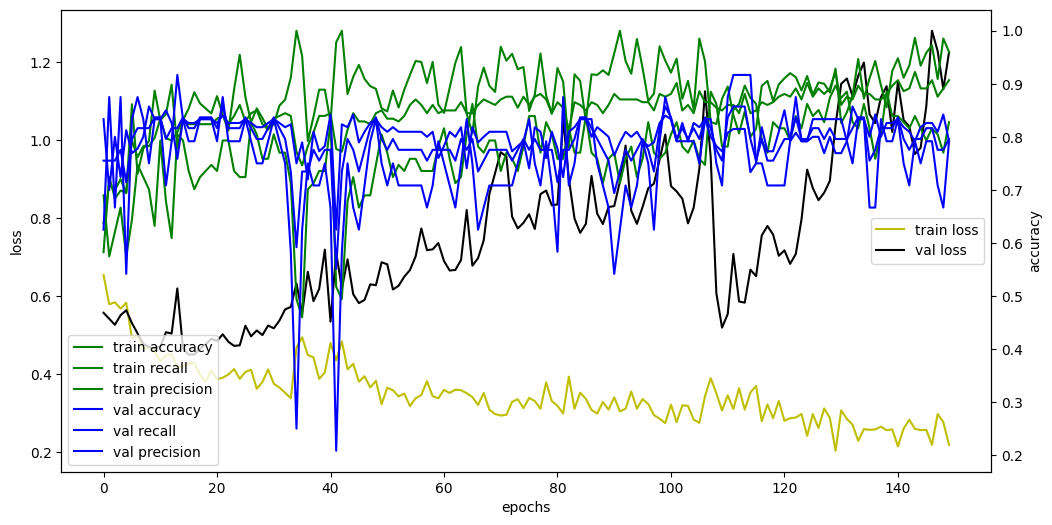

In [17]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['recall_2'], 'g', label='train recall')
acc_ax.plot(hist.history['precision_2'], 'g', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.plot(hist.history['val_recall_2'], 'b', label='val recall')
acc_ax.plot(hist.history['val_precision_2'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [19]:
score = model.evaluate(X_test, y_test, verbose=0)
print('model loss : ', score[0])
print('model accuracy : ', score[1])
print('model recall : ', score[2])
print('model precision : ', score[3])

model loss :  0.5899801850318909
model accuracy :  0.868852436542511
model recall :  0.8928571343421936
model precision :  0.8333333134651184


In [20]:
# 교차표
y_test.reshape(-1) # 실제값

array([0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.,
       1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 1., 1., 0., 1., 0., 1., 0., 1.])

In [21]:
y_hat = (model.predict(X_test)>0.5).astype(int).reshape(-1)
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'], colnames=['예측값'])

2/2 [==============================] - 0s 16ms/step


예측값,0,1
실제값,,
0.0,28,5
1.0,3,25


# 4. 모델 사용(저장, 예측)

In [23]:
from tensorflow.keras.models import save_model, load_model
model.save('model/07_heart.h5')
save_model(model, 'model/07_heart.h5')

In [24]:
model2 = load_model('model/07_heart.h5')

# 분류분석
```
1. 데이터 셋 생성 & 전처리
    엑셀 -> 데이터프레임 -> ?처리(df.replace('?', np.nan) -> 결측치 처리
       -> X, y 분리 -> X변수 스케일 조정 -> train_test_split함수로 학습셋과 테스트셋 분리
       -> y 변수들의 원핫인코딩
2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측)
```

# 1. 데이터 셋 생성 & 전처리
- 위와동일+원핫인코딩

In [25]:
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
Y_train.shape, Y_test.shape

((242, 2), (61, 2))

# 2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습

In [27]:
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=13, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=2, activation='softmax'))
model.summary()

from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

hist = model.fit(X_train, Y_train, # 훈련데이터
                epochs=150, # 학습횟수
#                 batch_size=227, # 한번에 읽어들이는 데이터 양
#                 validation_data=(X_test, y_test) # 검증 데이터
                validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
#                 verbose=1 # 학습 로그 출력 여부 (0: 출력x, 1:출력o(default), 2:출력자세히o)
                )

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 13)                182       
                                                                 
 dropout_16 (Dropout)        (None, 13)                0         
                                                                 
 dense_21 (Dense)            (None, 32)                448       
                                                                 
 dropout_17 (Dropout)        (None, 32)                0         
                                                                 
 dense_22 (Dense)            (None, 64)                2112      
                                                                 
 dropout_18 (Dropout)        (None, 64)                0         
                                                                 
 dense_23 (Dense)            (None, 32)               

Epoch 30/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3579 - accuracy: 0.8342 - recall_3: 0.8342 - precision_3: 0.8342 - val_loss: 0.4982 - val_accuracy: 0.7755 - val_recall_3: 0.7755 - val_precision_3: 0.7755
Epoch 31/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3325 - accuracy: 0.8497 - recall_3: 0.8497 - precision_3: 0.8497 - val_loss: 0.5558 - val_accuracy: 0.7755 - val_recall_3: 0.7755 - val_precision_3: 0.7755
Epoch 32/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3926 - accuracy: 0.8446 - recall_3: 0.8446 - precision_3: 0.8446 - val_loss: 0.5477 - val_accuracy: 0.7755 - val_recall_3: 0.7755 - val_precision_3: 0.7755
Epoch 33/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3455 - accuracy: 0.8394 - recall_3: 0.8394 - precision_3: 0.8394 - val_loss: 0.5342 - val_accuracy: 0.7755 - val_recall_3: 0.7755 - val_precision_3: 0.7755
Epoch 34/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3279 -

Epoch 66/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3069 - accuracy: 0.8653 - recall_3: 0.8653 - precision_3: 0.8653 - val_loss: 1.0156 - val_accuracy: 0.7143 - val_recall_3: 0.7143 - val_precision_3: 0.7143
Epoch 67/150
7/7 [==============================] - 0s 6ms/step - loss: 0.3971 - accuracy: 0.8601 - recall_3: 0.8601 - precision_3: 0.8601 - val_loss: 0.5458 - val_accuracy: 0.7755 - val_recall_3: 0.7755 - val_precision_3: 0.7755
Epoch 68/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3967 - accuracy: 0.8187 - recall_3: 0.8187 - precision_3: 0.8187 - val_loss: 0.5004 - val_accuracy: 0.6735 - val_recall_3: 0.6735 - val_precision_3: 0.6735
Epoch 69/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3672 - accuracy: 0.8808 - recall_3: 0.8808 - precision_3: 0.8808 - val_loss: 0.7692 - val_accuracy: 0.7143 - val_recall_3: 0.7143 - val_precision_3: 0.7143
Epoch 70/150
7/7 [==============================] - 0s 7ms/step - loss: 0.4327 -

Epoch 102/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3150 - accuracy: 0.8912 - recall_3: 0.8912 - precision_3: 0.8912 - val_loss: 1.0697 - val_accuracy: 0.7143 - val_recall_3: 0.7143 - val_precision_3: 0.7143
Epoch 103/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2799 - accuracy: 0.8756 - recall_3: 0.8756 - precision_3: 0.8756 - val_loss: 1.5391 - val_accuracy: 0.6939 - val_recall_3: 0.6939 - val_precision_3: 0.6939
Epoch 104/150
7/7 [==============================] - 0s 9ms/step - loss: 0.2231 - accuracy: 0.9067 - recall_3: 0.9067 - precision_3: 0.9067 - val_loss: 1.9579 - val_accuracy: 0.7347 - val_recall_3: 0.7347 - val_precision_3: 0.7347
Epoch 105/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2756 - accuracy: 0.8964 - recall_3: 0.8964 - precision_3: 0.8964 - val_loss: 2.4379 - val_accuracy: 0.7347 - val_recall_3: 0.7347 - val_precision_3: 0.7347
Epoch 106/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3

7/7 [==============================] - 0s 11ms/step - loss: 0.4174 - accuracy: 0.8446 - recall_3: 0.8446 - precision_3: 0.8446 - val_loss: 1.3068 - val_accuracy: 0.7143 - val_recall_3: 0.7143 - val_precision_3: 0.7143
Epoch 138/150
7/7 [==============================] - 0s 8ms/step - loss: 0.3478 - accuracy: 0.8238 - recall_3: 0.8238 - precision_3: 0.8238 - val_loss: 1.0023 - val_accuracy: 0.6531 - val_recall_3: 0.6531 - val_precision_3: 0.6531
Epoch 139/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3348 - accuracy: 0.8601 - recall_3: 0.8601 - precision_3: 0.8601 - val_loss: 1.2203 - val_accuracy: 0.6735 - val_recall_3: 0.6735 - val_precision_3: 0.6735
Epoch 140/150
7/7 [==============================] - 0s 7ms/step - loss: 0.3145 - accuracy: 0.8653 - recall_3: 0.8653 - precision_3: 0.8653 - val_loss: 1.4086 - val_accuracy: 0.6735 - val_recall_3: 0.6735 - val_precision_3: 0.6735
Epoch 141/150
7/7 [==============================] - 0s 8ms/step - loss: 0.2952 - accurac

# 3. 모델 평가(그래프, 평가, 교차표)

In [28]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_3', 'precision_3', 'val_loss', 'val_accuracy', 'val_recall_3', 'val_precision_3'])

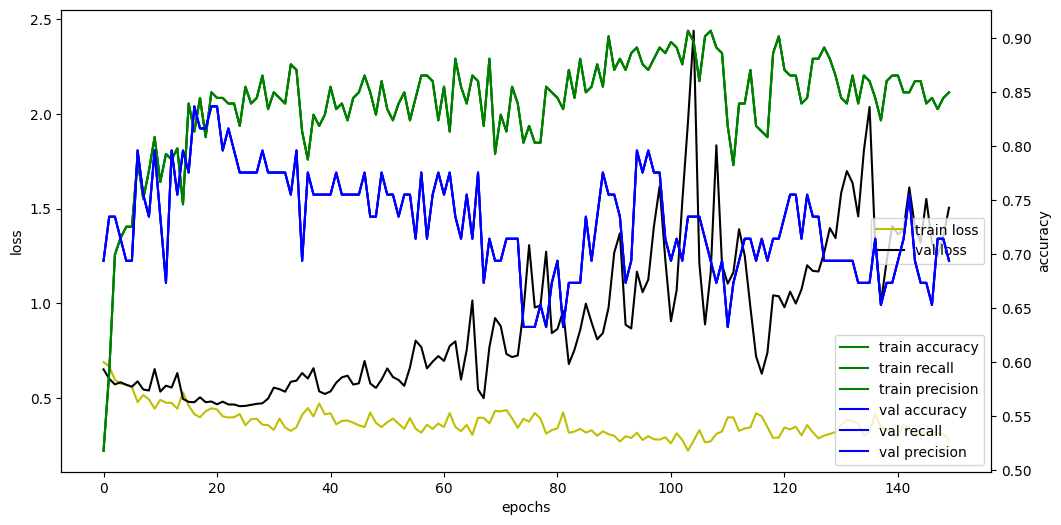

In [29]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['recall_3'], 'g', label='train recall')
acc_ax.plot(hist.history['precision_3'], 'g', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.plot(hist.history['val_recall_3'], 'b', label='val recall')
acc_ax.plot(hist.history['val_precision_3'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [31]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('model loss : ', score[0])
print('model accuracy : ', score[1])
print('model recall : ', score[2])
print('model precision : ', score[3])

model loss :  0.5605437755584717
model accuracy :  0.8852459192276001
model recall :  0.8852459192276001
model precision :  0.8852459192276001


In [35]:
# 교차표
y_hat = model.predict(X_test).argmax(axis=1)
y_hat
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

2/2 [==============================] - 0s 3ms/step


예측값,0,1
실제값,,
0.0,29,4
1.0,3,25


# 4. 모델 사용(저장, 예측)